In [4]:
!pip install  scikit-misc


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [1]:
import scanpy as sc

adata = sc.read_h5ad("DLPFC_151507_ST_final.h5ad")

print(adata)
print(adata.obs.columns)
print(adata.obsm.keys())

AnnData object with n_obs × n_vars = 4221 × 3010
    obs: 'in_tissue', 'array_row', 'array_col', 'Ground Truth', 'n_genes', 'image_cluster', 'dbscan_cluster_new'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells', 'n_counts'
    uns: 'image_cluster_colors', 'log1p', 'spatial'
    obsm: 'X_pca', 'features', 'features_summary_scale0.5_0.5', 'features_summary_scale0.5_1', 'features_summary_scale0.5_2', 'features_summary_scale1_0.5', 'features_summary_scale1_1', 'features_summary_scale1_2', 'features_summary_scale2_0.5', 'features_summary_scale2_1', 'features_summary_scale2_2', 'spatial'
    obsp: 'adj_f', 'adj_i', 'adj_t'
Index(['in_tissue', 'array_row', 'array_col', 'Ground Truth', 'n_genes',
       'image_cluster', 'dbscan_cluster_new'],
      dtype='object')
KeysView(AxisArrays with keys: X_pca, features, features_summary_scale0.5_0.5, features_summary_scale0.5_1, features_summary_scale0.5_2, features_summary_scale1_0.5, features_summary_scale1_1, features_summary_scale1_2, feat

/Users/muradyan.e/wut/bioinform/.venv/lib/python3.11/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


In [2]:
import scanpy as sc

# Identify HVGs
sc.pp.highly_variable_genes(
    adata,
    n_top_genes=2000,
    flavor="seurat_v3"
)

# Subset to HVGs
adata_hvg = adata[:, adata.var["highly_variable"]].copy()

print(adata_hvg.shape)

(4221, 2000)


/Users/muradyan.e/wut/bioinform/.venv/lib/python3.11/site-packages/legacy_api_wrap/__init__.py:88: UserWarning: `flavor='seurat_v3'` expects raw count data, but non-integers were found.
  return fn(*args_all, **kw)


In [3]:
sc.pp.normalize_total(adata_hvg, target_sum=1e4)
sc.pp.log1p(adata_hvg)
sc.pp.scale(adata_hvg)

/opt/homebrew/Cellar/python@3.11/3.11.14_1/Frameworks/Python.framework/Versions/3.11/lib/python3.11/functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


In [4]:
sc.pp.pca(adata_hvg, n_comps=50)

In [5]:
X = adata_hvg.obsm["X_pca"][:, :5]

print(X.shape)  # should be (4221, 5)

(4221, 5)


In [6]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [7]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")

X_tensor = torch.tensor(X_scaled, dtype=torch.float32).to(device)
X_tensor = X_tensor.unsqueeze(1)  # (S, 1, 5)

print(X_tensor.shape)

torch.Size([4221, 1, 5])


In [8]:
num_clusters = torch.zeros((4222, 1), dtype=torch.long).to(device)

In [9]:
import transformer
import torch


model = transformer.Transformer(
    d_model=256,
    nhead=4,
    nhid=512,
    nlayers=4,
    in_features=5,
    buckets_size=10
).to(device)

checkpoint = torch.load("pfn_hard_5D.pt", map_location=device)
model.load_state_dict(checkpoint["model_state_dict"])

model.eval()

/Users/muradyan.e/wut/bioinform/.venv/lib/python3.11/site-packages/torch/nn/modules/transformer.py:144: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  self.encoder = TransformerEncoder(


Transformer(
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-3): 4 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True)
        )
        (linear1): Linear(in_features=256, out_features=512, bias=True)
        (dropout): Dropout(p=0, inplace=False)
        (linear2): Linear(in_features=512, out_features=256, bias=True)
        (norm1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0, inplace=False)
        (dropout2): Dropout(p=0, inplace=False)
      )
    )
    (norm): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
  )
  (decoder): Linear(in_features=256, out_features=10, bias=True)
  (linear_x): Linear(in_features=5, out_features=256, bias=True)
  (linear_num_clusters): Linear(in_features=5, out_features=256, bias=True)
  (embedding): E

In [11]:
with torch.no_grad():
    output_points, output_cluster = model(X_tensor, num_clusters)

pred = output_points.squeeze(1).argmax(dim=-1).cpu().numpy()

In [12]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

ari = adjusted_rand_score(adata.obs["Ground Truth"], pred)
nmi = normalized_mutual_info_score(adata.obs["Ground Truth"], pred)

print("HVG + PCA (5 PCs) ARI:", ari)
print("HVG + PCA (5 PCs) NMI:", nmi)

HVG + PCA (5 PCs) ARI: 0.0074188254406247255
HVG + PCA (5 PCs) NMI: 0.03518748986613629


In [13]:
adata.obs["cluster_pfn_hv"] = pred.astype(str)
adata.obs["cluster_pfn_hv"] = adata.obs["cluster_pfn_hv"].astype("category")

/var/folders/_t/3h6whhf57fb6936zy09qr12m0000gq/T/ipykernel_13475/2698542579.py:1: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata, color=["Ground Truth", "cluster_pfn_hv"], size=1.5, ncols=2)


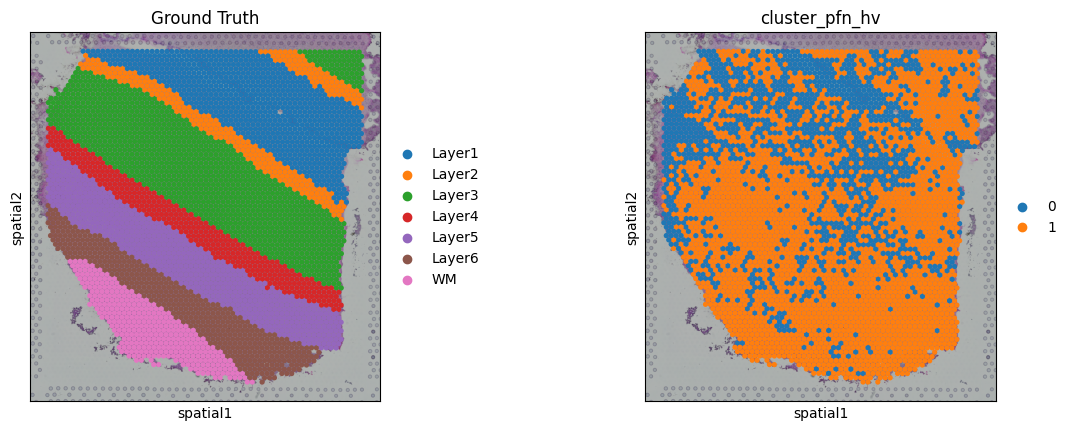

In [15]:
sc.pl.spatial(adata, color=["Ground Truth", "cluster_pfn_hv"], size=1.5, ncols=2)

## Spatial Smoothing


In [17]:
import numpy as np
from sklearn.neighbors import NearestNeighbors

# use spatial coordinates
coords = adata.obsm["spatial"]

# find neighbors
nbrs = NearestNeighbors(n_neighbors=6).fit(coords)
_, indices = nbrs.kneighbors(coords)

X_expr = adata.X  # or adata_hvg.X if you want HVGs
if not isinstance(X_expr, np.ndarray):
    X_expr = X_expr.toarray()
# smooth expression
X_smooth = np.zeros_like(X_expr)

for i in range(X_expr.shape[0]):
    X_smooth[i] = X_expr[indices[i]].mean(axis=0)

In [18]:

from sklearn.decomposition import PCA

pca = PCA(n_components=5)
X_pca = pca.fit_transform(X_smooth)

In [19]:
X_tensor_pca = torch.tensor(X_pca, dtype=torch.float32).to(device)
X_tensor_pca = X_tensor_pca.unsqueeze(1)  # (S, 1, 5)

print(X_tensor_pca.shape)

torch.Size([4221, 1, 5])


In [22]:
with torch.no_grad():
    output_points, output_cluster = model(X_tensor_pca, num_clusters)

pred = output_points.squeeze(1).argmax(dim=-1).cpu().numpy()

In [23]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

ari = adjusted_rand_score(adata.obs["Ground Truth"], pred)
nmi = normalized_mutual_info_score(adata.obs["Ground Truth"], pred)

print("HVG + PCA (5 PCs) ARI:", ari)
print("HVG + PCA (5 PCs) NMI:", nmi)

HVG + PCA (5 PCs) ARI: 0.12540696121076655
HVG + PCA (5 PCs) NMI: 0.20449895929097045


This experiment compares the effect of different preprocessing strategies on Cluster-PFN performance.

Using highly variable gene selection followed by PCA resulted in a significant drop in performance, with ARI decreasing to approximately 0.007. This suggests that selecting features based purely on variance does not align well with the clustering assumptions of the model.

In contrast, applying spatial smoothing before dimensionality reduction led to a substantial improvement, increasing ARI to approximately 0.125.

This indicates that incorporating spatial structure into the feature representation is far more important than standard feature selection in this setting.

The results suggest that the model benefits from spatially coherent inputs, even though it does not explicitly model spatial relationships.

In [24]:
adata.obs["cluster_pfn_hv_smooth"] = pred.astype(str)
adata.obs["cluster_pfn_hv_smooth"] = adata.obs["cluster_pfn_hv_smooth"].astype("category")

/var/folders/_t/3h6whhf57fb6936zy09qr12m0000gq/T/ipykernel_13475/2631895641.py:1: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata, color=["Ground Truth", "cluster_pfn_hv_smooth"], size=1.5, ncols=2)


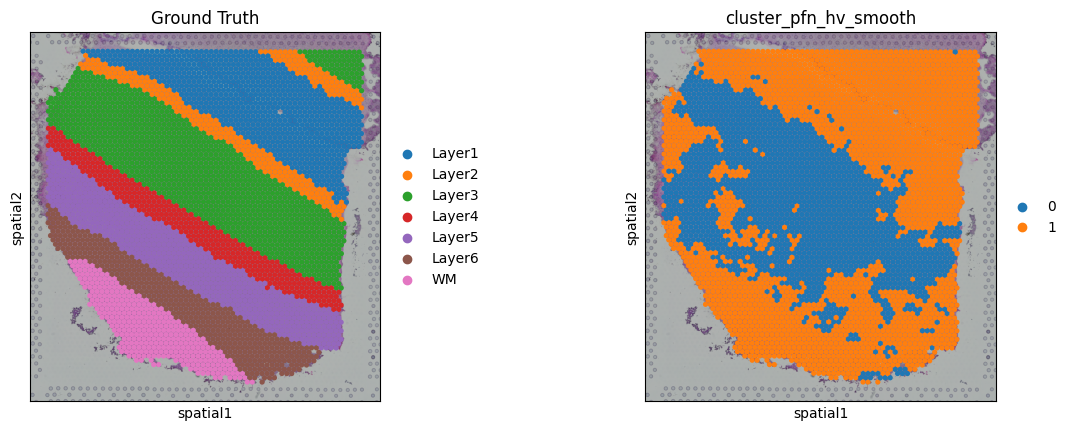

In [25]:
sc.pl.spatial(adata, color=["Ground Truth", "cluster_pfn_hv_smooth"], size=1.5, ncols=2)